sample datasetL:
   weather   soil temperature humidity    wind fertilizer crop type  season  \
0   rainy  moist         hot     high    weak        yes      rice    rabi   
1   sunny    dry        cool      low    weak        yes     wheat    rabi   
2   rainy  moist        mild   medium  strong        yes     wheat  kharif   
3   rainy  moist        cool     high  strong        yes     wheat  kharif   
4   sunny  moist        cool     high    weak         no     wheat  kharif   

  irrigate  
0       no  
1      yes  
2       no  
3       no  
4       no  

Accuracy Comparision:
Decision tree Accuracy: 0.9444444444444444
Random Forest Accuracy: 0.8888888888888888

Decision Tree Confusion Matrix:
             Predicted No  Predicted Yes
Actual No              4              0
Actual Yes             0              5

Random Forest Confusion Matrix:
             Predicted No  Predicted Yes
Actual No              5              0
Actual Yes             0              5


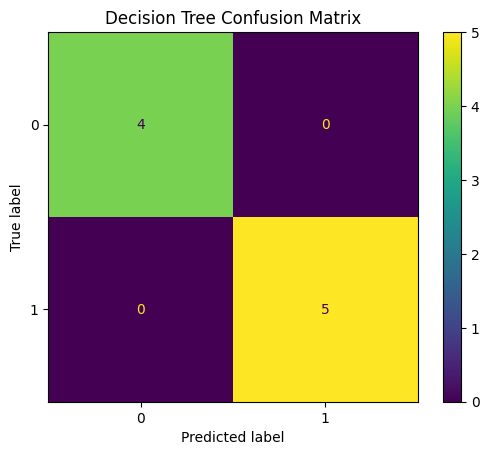

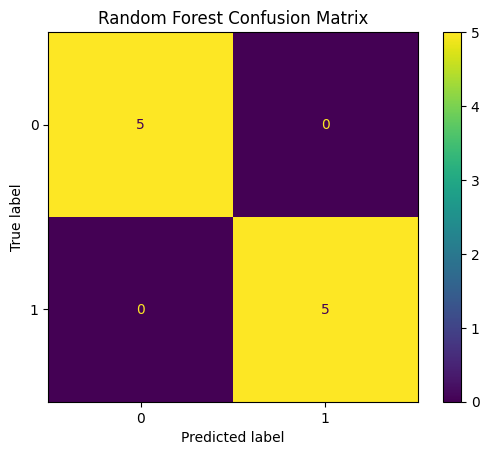


 Cross Validation Accuracy:
Decision Tree: 0.7833333333333333
Random Forest: 0.8

Feature Importance:
        feature  importance
1         soil    0.433302
6    crop type    0.115520
3     humidity    0.106780
0      weather    0.101652
7       season    0.080832
4         wind    0.066359
2  temperature    0.051891
5   fertilizer    0.043664


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay


# generate larger farming dataset
np.random.seed(42)
n_samples=60
data={
    'weather':np.random.choice(['sunny','cloudy','rainy'],n_samples),
    'soil':np.random.choice(['dry','moist','wet'],n_samples),
    'temperature':np.random.choice(['hot','mild','cool'],n_samples),
    'humidity':np.random.choice(['high','medium','low'],n_samples),
    'wind':np.random.choice(['strong','weak'],n_samples),
    'fertilizer':np.random.choice(['yes','no'],n_samples),
    'crop type':np.random.choice(['corn','wheat','rice'],n_samples),
    'season':np.random.choice(['kharif','rabi','corn'],n_samples)
}
df=pd.DataFrame(data)

#3 Cerate target variable

def irrigation_rule(row):
  if row['soil']=='dry'and row['weather']!='rainy':
    return'yes'
  elif row['soil']=='wet':
    return'now'
  elif row['humidity']=='high'and row['weather']=='rainy':
    return'no'
  else:
    return np.random.choice(['yes','no'])
df['irrigate']=df.apply(irrigation_rule,axis=1)
print("sample datasetL:\n",df.head())

#4 Encode Categorical Variables
le_dict={}

for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le

#5 Split Features and Target
X=df.drop('irrigate',axis=1)
y=df['irrigate']

#6 train-test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
#7 Decision tree model
dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

#8 Random forest model
rf_model=RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42
)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

#9 Accuracy evaluation
dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)

print("\nAccuracy Comparision:")
print("Decision tree Accuracy:",dt_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

#10 Confusion Matrix (fixed+ meaningful)
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

cm_dt_df=pd.DataFrame(cm_dt,index=['Actual No','Actual Yes'],columns=['Predicted No','Predicted Yes'])
cm_rf_df=pd.DataFrame(cm_rf,index=['Actual No','Actual Yes'],columns=['Predicted No','Predicted Yes'])

print("\nDecision Tree Confusion Matrix:\n",cm_dt_df)
print("\nRandom Forest Confusion Matrix:\n",cm_rf_df)

#11 Confusion Matrix Visualization
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()

#12 Cross Validation
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n Cross Validation Accuracy:")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())

#13 Feature Importance(random Forest)
importance=pd.DataFrame({
    'feature':X.columns,
    'importance':rf_model.feature_importances_
}).sort_values(by='importance',ascending=False)

print("\nFeature Importance:\n",importance)
